In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

import kagglehub

import matplotlib.pyplot as plt

import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

print(device)

cuda


In [20]:
from torchmetrics.functional.image import structural_similarity_index_measure as ssim_fn

#fixing blur issue with SSIM and L1 loss
class BlurFixLoss(nn.Module):
    def __init__(self, alpha=0.84, data_range=2.0):
        super().__init__()
        # L1 checks basic pixel values
        self.l1 = nn.L1Loss()
        self.alpha = alpha
        # data is [-1,1] from Normalize(0.5,0.5) + Tanh, so the range is 2.0
        self.data_range = data_range

    def forward(self, preds, targets):
        # SSIM checks sharp lines/edges
        ssim_loss = 1.0 - ssim_fn(preds, targets, data_range=self.data_range)
        l1_loss = self.l1(preds, targets)
        return (self.alpha * ssim_loss) + ((1 - self.alpha) * l1_loss)

In [28]:
#adjustable parameters
from AutoEncoder import AutoEncoder

batch_size = 256
epochs = 50
lr = 1e-4
latent_dim = 256
num_workers = 8


model = AutoEncoder(latent_dim=latent_dim).to(device)

criterion = BlurFixLoss(alpha=0.6).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

In [23]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")
full_dataset += '\\RetinalOCT_Dataset\\RetinalOCT_Dataset' 

train_dataset = ImageFolder(
    root=full_dataset+'\\train',
    transform=transform
)

train_loader = DataLoader(
   dataset=train_dataset,
   batch_size=batch_size,
   shuffle=True,
   #increases compute speed
   num_workers=num_workers,
   pin_memory=True,
   persistent_workers=True
)

test_dataset = ImageFolder(
    root= full_dataset+'\\test',
    transform=transform
)

test_loader = DataLoader(
   dataset=test_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=num_workers,
   pin_memory=True,
   persistent_workers=True
)

In [29]:
#Training Loop
scaler = torch.amp.GradScaler(device.type)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type):
            outputs = model(images)

        # fp32 - SSIM underflows in half precision
        loss = criterion(outputs.float(), images)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}, Scale: {scaler.get_scale():.0f}')

Epoch [1/50], Average Loss: 0.7048, Scale: 32768
Epoch [2/50], Average Loss: 0.4427, Scale: 32768
Epoch [3/50], Average Loss: 0.4216, Scale: 32768
Epoch [4/50], Average Loss: 0.3219, Scale: 32768
Epoch [5/50], Average Loss: 0.2929, Scale: 32768
Epoch [6/50], Average Loss: 0.2853, Scale: 32768
Epoch [7/50], Average Loss: 0.2802, Scale: 32768
Epoch [8/50], Average Loss: 0.2737, Scale: 32768
Epoch [9/50], Average Loss: 0.2594, Scale: 32768
Epoch [10/50], Average Loss: 0.2503, Scale: 32768
Epoch [11/50], Average Loss: 0.2452, Scale: 32768
Epoch [12/50], Average Loss: 0.2410, Scale: 32768
Epoch [13/50], Average Loss: 0.2375, Scale: 32768
Epoch [14/50], Average Loss: 0.2330, Scale: 32768
Epoch [15/50], Average Loss: 0.2283, Scale: 32768
Epoch [16/50], Average Loss: 0.2243, Scale: 32768
Epoch [17/50], Average Loss: 0.2208, Scale: 32768
Epoch [18/50], Average Loss: 0.2179, Scale: 32768
Epoch [19/50], Average Loss: 0.2152, Scale: 32768
Epoch [20/50], Average Loss: 0.2131, Scale: 32768
Epoch [21

In [31]:
torch.save(model.state_dict(), "models\\oct_autoencoder_model.pth")

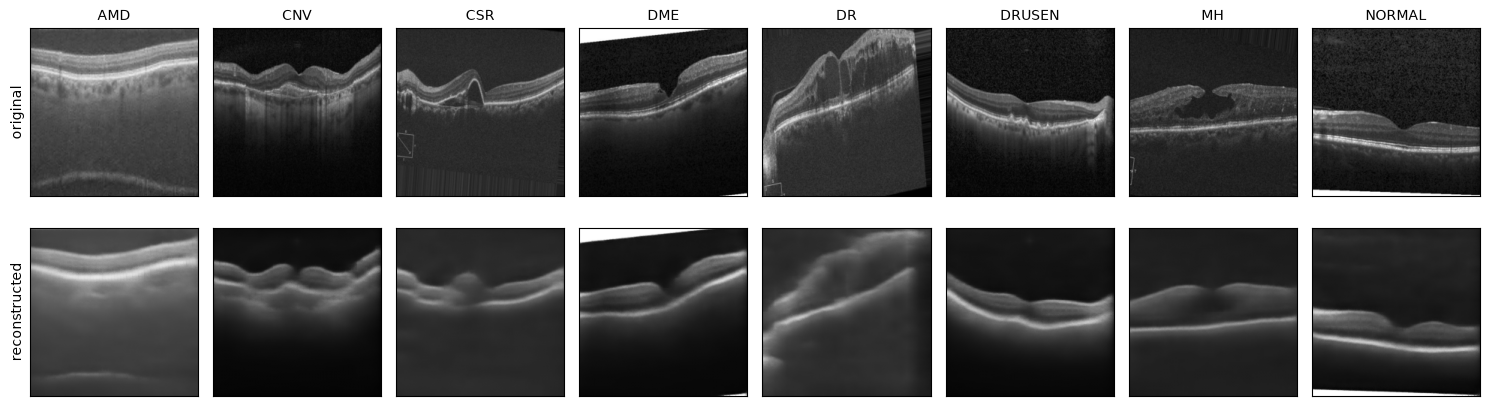

In [30]:
#Visualization
def visualize_reconstruction(model, data_loader):
    model.eval()

    found = {}
    for images, labels in data_loader:
        for img, lab in zip(images, labels):
            c = lab.item()
            if c not in found:
                found[c] = img
        if len(found) == 8:
            break

    class_ids = sorted(found)
    batch = torch.stack([found[c] for c in class_ids]).to(device)

    with torch.no_grad():
        reconstructed = model(batch)

    class_names = data_loader.dataset.classes

    fig, axes = plt.subplots(2, 8, figsize=(15, 4.5))
    for i, c in enumerate(class_ids):
        orig  = (batch[i].cpu().squeeze() + 1) / 2
        recon = (reconstructed[i].cpu().squeeze() + 1) / 2

        axes[0, i].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(class_names[c], fontsize=10)

        axes[1, i].imshow(recon, cmap='gray', vmin=0, vmax=1)

        for ax in (axes[0, i], axes[1, i]):
            ax.set_xticks([])
            ax.set_yticks([])

    axes[0, 0].set_ylabel("original", fontsize=10)
    axes[1, 0].set_ylabel("reconstructed", fontsize=10)

    plt.tight_layout()
    plt.savefig("result_images/reconstruction_grid.png", dpi=200, bbox_inches='tight')
    plt.show()


test = AutoEncoder(256).to(device)
weights = torch.load("models/oct_autoencoder_model.pth", map_location=device, weights_only=True)
test.load_state_dict(weights)
visualize_reconstruction(model, test_loader)

In [8]:
#test
model.eval()
total_loss = 0
mse = nn.MSELoss()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        reconstructions = model(images)

        loss = mse(reconstructions, images)
        total_loss += loss.item()

print("avg_loss", total_loss / len(test_loader))

avg_loss 0.3135112537579103
